In [3]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 

In [4]:
from sklearn.datasets import fetch_california_housing

housing = fetch_california_housing(as_frame=True)

In [5]:
housing.data.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [6]:
housing.target.head()

0    4.526
1    3.585
2    3.521
3    3.413
4    3.422
Name: MedHouseVal, dtype: float64

In [7]:
x = housing.data
y = housing.target

In [8]:
df = housing.data.copy()
df["Price"] = housing.target
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


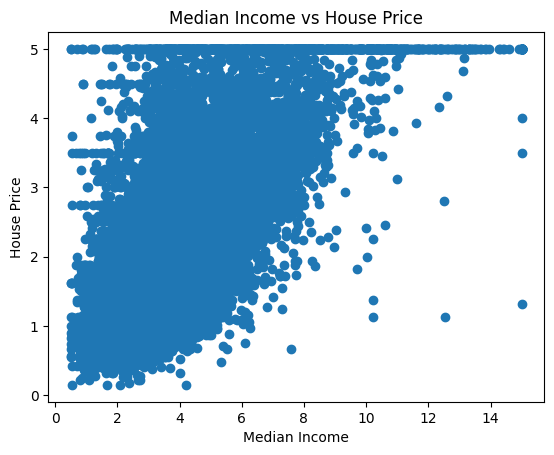

In [9]:
plt.scatter(df["MedInc"], df["Price"])
plt.xlabel("Median Income")
plt.ylabel("House Price")
plt.title("Median Income vs House Price")

plt.show()

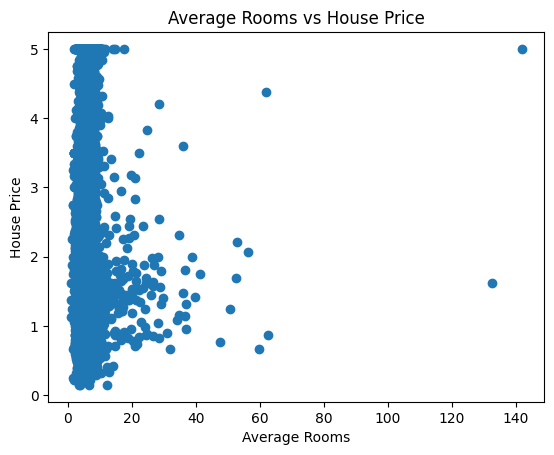

In [10]:
plt.scatter(df["AveRooms"], df["Price"])
plt.xlabel("Average Rooms")
plt.ylabel("House Price")
plt.title("Average Rooms vs House Price")

plt.show()

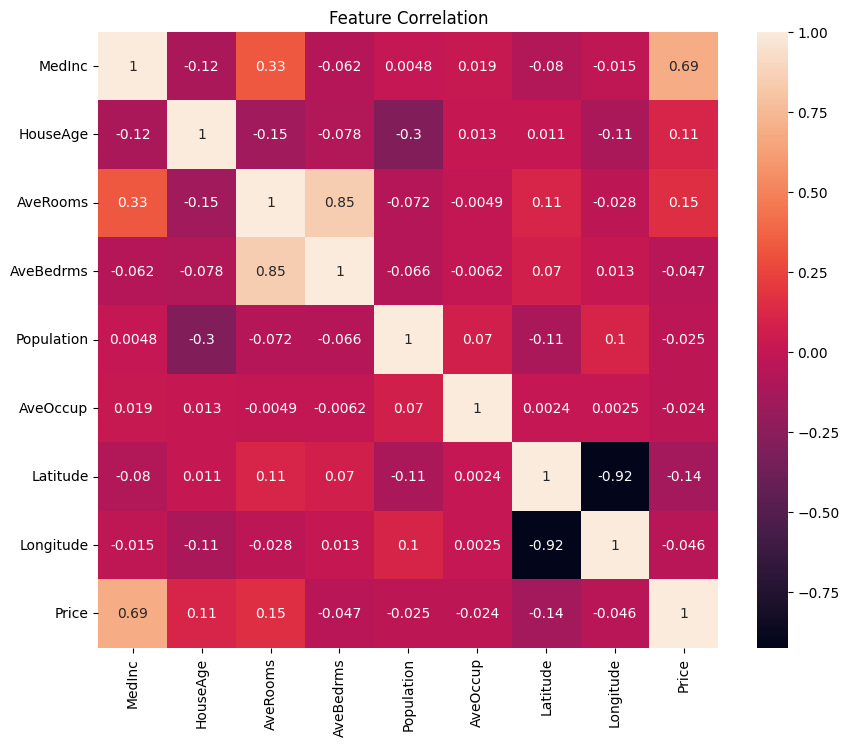

In [11]:
plt.figure(figsize=(10, 8))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True
)

plt.title("Feature Correlation")
plt.show()

In [32]:
X = df.drop(columns=["Price"])
y = df["Price"]

In [35]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

X_train.shape

(16512, 8)

In [36]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

In [37]:
predictions = model.predict(X_test)
predictions[:5]

comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": predictions
})

comparison.head(10)

/Users/alexlien/Desktop/CS Projects/housing-price-predictor/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/alexlien/Desktop/CS Projects/housing-price-predictor/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/alexlien/Desktop/CS Projects/housing-price-predictor/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_


,Actual,Predicted
0,0.47700,0.719123
1,0.45800,1.764017
2,5.00001,2.709659
3,2.18600,2.838926
4,2.78000,2.604657
5,1.58700,2.011754
6,1.98200,2.645500
7,1.57500,2.168755
8,3.40000,2.740746
9,4.46600,3.915615


In [40]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, predictions)
mse = mean_squared_error(y_test, predictions)
r2 = r2_score(y_test, predictions)
rmse= np.sqrt(mse)

print("MAE: ", mae)
print("MSE: ", mse)
print("RMSE: ", rmse)
print("Rsq: ", r2)

MAE:  0.5332001304956555
MSE:  0.5558915986952443
RMSE:  0.7455813830127763
Rsq:  0.5757877060324508


In [42]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

coefficients

,Feature,Coefficient
0,MedInc,0.448675
1,HouseAge,0.009724
2,AveRooms,-0.123323
3,AveBedrms,0.783145
4,Population,-0.000002
5,AveOccup,-0.003526
6,Latitude,-0.419792
7,Longitude,-0.433708


In [45]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train.head()
X_train_scaled[:5]


array([[-0.326196  ,  0.34849025, -0.17491646, -0.20836543,  0.76827628,
         0.05137609, -1.3728112 ,  1.27258656],
       [-0.03584338,  1.61811813, -0.40283542, -0.12853018, -0.09890135,
        -0.11736222, -0.87669601,  0.70916212],
       [ 0.14470145, -1.95271028,  0.08821601, -0.25753771, -0.44981806,
        -0.03227969, -0.46014647, -0.44760309],
       [-1.01786438,  0.58654547, -0.60001532, -0.14515634, -0.00743434,
         0.07750687, -1.38217186,  1.23269811],
       [-0.17148831,  1.14200767,  0.3490073 ,  0.08662432, -0.48587717,
        -0.06883176,  0.5320839 , -0.10855122]])

In [46]:
scaled_model = LinearRegression()
scaled_model.fit(X_train_scaled, y_train)
scaled_predictions = scaled_model.predict(X_test_scaled)

scaled_mae = mean_absolute_error(y_test, scaled_predictions)
scaled_rmse = np.sqrt(mean_squared_error(y_test, scaled_predictions))
scaled_r2 = r2_score(y_test, scaled_predictions)

print("MAE:", scaled_mae)
print("RMSE:", scaled_rmse)
print("R²:", scaled_r2)

MAE: 0.5332001304956562
RMSE: 0.7455813830127763
R²: 0.575787706032451


/Users/alexlien/Desktop/CS Projects/housing-price-predictor/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/alexlien/Desktop/CS Projects/housing-price-predictor/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/alexlien/Desktop/CS Projects/housing-price-predictor/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_


In [52]:
from sklearn.ensemble import RandomForestRegressor

forest_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    random_state=42
)

forest_model.fit(X_train, y_train)
model.fit(X_train, y_train)

forest_predictions = forest_model.predict(X_test)

forest_mae = mean_absolute_error(y_test, forest_predictions)
forest_rmse = np.sqrt(
    mean_squared_error(y_test, forest_predictions)
)
forest_r2 = r2_score(y_test, forest_predictions)

print("MAE:", forest_mae)
print("RMSE:", forest_rmse)
print("R²:", forest_r2)

MAE: 0.36624865715728067
RMSE: 0.5444947498920153
R²: 0.7737541961457275


In [53]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": forest_model.feature_importances_
})

importance.sort_values(
    "Importance",
    ascending=False
)

,Feature,Importance
0,MedInc,0.593852
5,AveOccup,0.139770
6,Latitude,0.076576
7,Longitude,0.076055
1,HouseAge,0.047894
2,AveRooms,0.031560
4,Population,0.017223
3,AveBedrms,0.017071


In [54]:
from sklearn.model_selection import cross_val_score
cv_scores = cross_val_score(
    forest_model,
    X_train,
    y_train,
    cv=5,
    scoring="r2"
)

cv_scores.mean()

np.float64(0.7819109076340219)

In [ ]:
from sklearn.model_selection import GridSearchCV
forest = RandomForestRegressor(random_state=42)
param_grid = {
    "n_estimators": [50, 100, 200],
    "max_depth": [5, 10, 20]
}

grid_search = GridSearchCV(
    forest,
    param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)


GridSearchCV(cv=5, estimator=RandomForestRegressor(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [5, 10, 20],
                         'n_estimators': [50, 100, 200]},
             scoring='r2')

In [58]:

best_model = grid_search.best_estimator_
final_predictions = best_model.predict(X_test)
final_mae = mean_absolute_error(y_test, final_predictions)
final_rmse = np.sqrt(
    mean_squared_error(y_test, final_predictions)
)
final_r2 = r2_score(y_test, final_predictions)

print("Final MAE:", final_mae)
print("Final RMSE:", final_rmse)
print("Final R²:", final_r2)

Final MAE: 0.3272628439593016
Final RMSE: 0.5047673449853916
Final R²: 0.8055644636183484


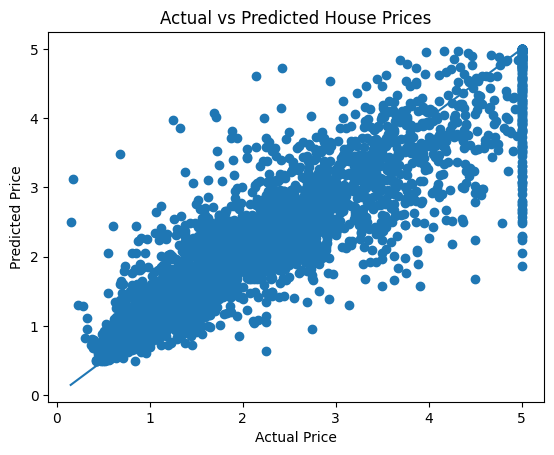

In [60]:
plt.scatter(y_test, final_predictions)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()]
)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted House Prices")

plt.show()

In [62]:
print("Final Model Performance")
print("-----------------------")
print(f"MAE:  {final_mae:.3f}")
print(f"RMSE: {final_rmse:.3f}")
print(f"R²:   {final_r2:.3f}")
print(f"Average error: ${final_mae * 100000:,.0f}")

Final Model Performance
-----------------------
MAE:  0.327
RMSE: 0.505
R²:   0.806
Average error: $32,726


In [63]:
import joblib
joblib.dump(best_model, "housing_price_model.pkl")

['housing_price_model.pkl']